In [1]:
from pathlib import Path
import numpy as np
import os, shutil
import matplotlib.pyplot as plt

from PIL import Image

from tqdm.auto import tqdm

import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torchsummary import summary
from torch.utils.data.dataset import Subset
from torch import nn

In [2]:
# extract dataset 

#import tarfile

#with tarfile.open('metal_nut.tar.xz') as f:
#    f.extractall('.')

Let's visualize some samples!

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

image_path = 'screw/test/scratch_head/000.png'
image = Image.open(image_path)
print(image.size)

(1024, 1024)


torch.Size([1, 224, 224])


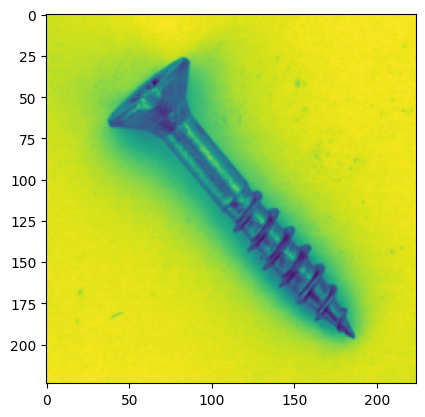

In [4]:
from torchvision.transforms import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

image = transform(image)

print(image.shape)

plt.imshow(image.permute(1, 2, 0))
plt.show()

Memory consumed by tensor

In [5]:
memory_usage = image.numel() * image.element_size()

print(f"Memory usage of the tensor: {memory_usage * 320 // 1024} KB") # 320 images

Memory usage of the tensor: 62720 KB


In [6]:
from torchvision.datasets import ImageFolder

train_image_path = 'screw/train'

good_dataset = ImageFolder(root=train_image_path, transform = transform)

x, y = good_dataset[0]

print("Image shape:", x.shape)
print("Label: ", y)

Image shape: torch.Size([3, 224, 224])
Label:  0


Train & test split the dataset

In [7]:
import torch

train_dataset, test_dataset = torch.utils.data.random_split(good_dataset, [0.8, 0.2])

print("Total samples in the original dataset: ", len(good_dataset))
print("Training dataset: ", len(train_dataset))
print("Testing dataset: ", len(test_dataset))


Total samples in the original dataset:  320
Training dataset:  256
Testing dataset:  64


Using dataloader to load data during training

In [8]:
import torch
from torch.utils.data import DataLoader

BS = 16

train_loader = DataLoader(train_dataset, batch_size = BS, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BS, shuffle = True)

image_batch, label_batch = next(iter(train_loader))

print(f"Shape of input images: {image_batch.shape}")
print(f"Shape of labels: {label_batch.shape}")

memory_usage = image_batch.numel() * image_batch.element_size()

print(f"Memory usage of the batch: {memory_usage // 1024} KB")

Shape of input images: torch.Size([16, 3, 224, 224])
Shape of labels: torch.Size([16])
Memory usage of the batch: 9408 KB


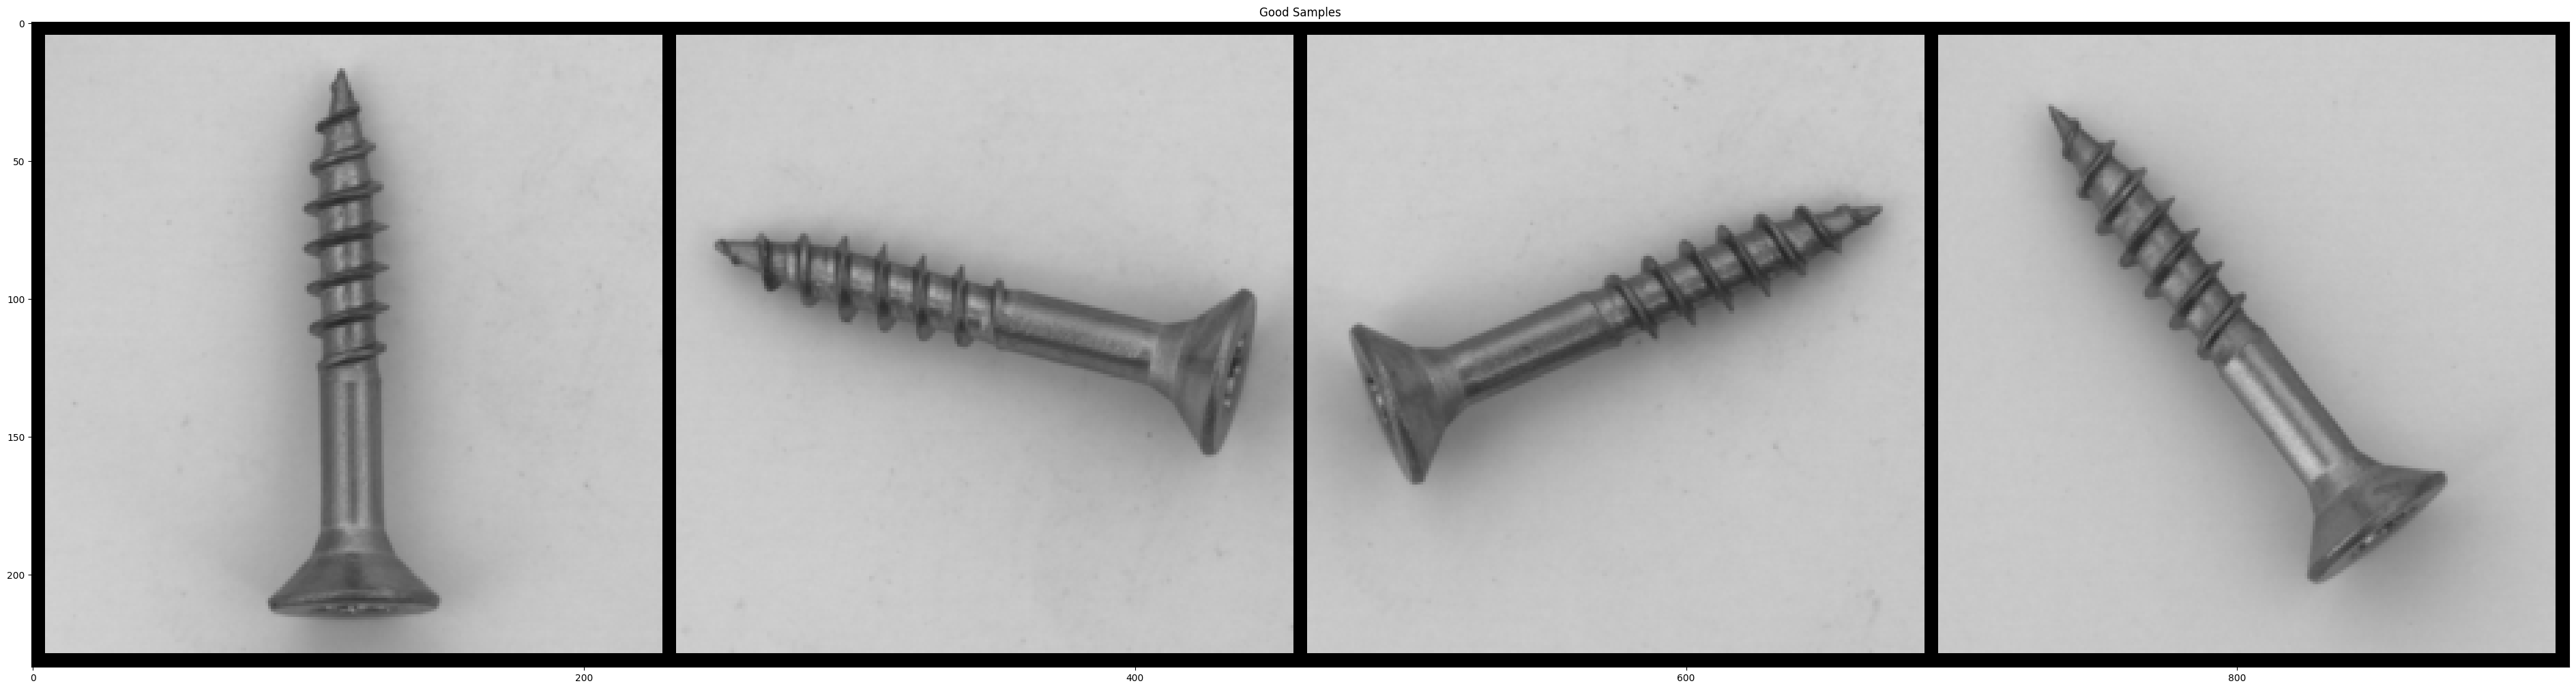

In [9]:
plt.figure(figsize=(12*4, 48*4))

grid = torchvision.utils.make_grid(image_batch[0:4], padding=5, nrow=4)
plt.imshow(grid.permute(1, 2, 0))
plt.title("Good Samples")
plt.show()

train the autoencoder model

In [10]:
import torch
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 128, kernel_size = 4),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size = 2, stride = 2),
            nn.Conv2d(128, 256, kernel_size = 4),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size = 2, stride = 2),
            nn.Conv2d(256, 256, kernel_size = 3),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size = 2, stride = 2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 256, kernel_size = 4, stride = 2, output_padding = 1),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size = 5, stride = 2, output_padding = 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 3, kernel_size = 5, stride = 2, output_padding = 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    

model = Autoencoder()
input_image = torch.randn(1, 3, 224, 224)
output_image = model(input_image)

print(output_image.shape)

torch.Size([1, 3, 224, 224])


In [11]:
# loss function & optimizer

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

Training loop

In [12]:
'''
Loss = []
Validation_loss = []

num_epochs = 100
for epoch in tqdm(range(num_epochs)):

    for img, _ in train_loader:
        
        output = model(img)
        loss = criterion(output, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    Loss.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_loss_sum = 0.0
        num_batches = 0
        for img, _ in test_loader:
            output = model(img)
            val_loss = criterion(output, img)
            val_loss_sum += val_loss.item()
            num_batches += 1
        val_loss_avg = val_loss_sum / num_batches
        Validation_loss.append(val_loss_avg)

    if epoch % 5 == 0:
        print("Epoch [{}/{}], Loss: {: 4f}, Validation Loss: {: 4f}".format(epoch + 1, num_epochs, loss.item(), val_loss_avg))  
    
plt.plot(Loss, label = 'Training Loss')
plt.plot(Validation_loss, label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()
'''

'\nLoss = []\nValidation_loss = []\n\nnum_epochs = 100\nfor epoch in tqdm(range(num_epochs)):\n\n    for img, _ in train_loader:\n\n        output = model(img)\n        loss = criterion(output, img)\n\n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n    Loss.append(loss.item())\n\n    model.eval()\n    with torch.no_grad():\n        val_loss_sum = 0.0\n        num_batches = 0\n        for img, _ in test_loader:\n            output = model(img)\n            val_loss = criterion(output, img)\n            val_loss_sum += val_loss.item()\n            num_batches += 1\n        val_loss_avg = val_loss_sum / num_batches\n        Validation_loss.append(val_loss_avg)\n\n    if epoch % 5 == 0:\n        print("Epoch [{}/{}], Loss: {: 4f}, Validation Loss: {: 4f}".format(epoch + 1, num_epochs, loss.item(), val_loss_avg))  \n\nplt.plot(Loss, label = \'Training Loss\')\nplt.plot(Validation_loss, label = \'Validation Loss\')\nplt.xlabel(\'Epochs\')\nplt.ylabel(\'Loss

In [13]:
# save the model (kalo mau save, yang bawah (load) di comment dulu)

#torch.save(model.state_dict(), 'simple_autoencoder_screwdata.pth')
#model.eval()

# load the model (kalo mau load, yg atas (save) di comment dulu)

checkpoint = torch.load('simple_autoencoder_screwdata.pth')
model.load_state_dict(checkpoint)

<All keys matched successfully>

Reconstruction of good images

torch.Size([16, 224, 224])


<Figure size 1600x1200 with 0 Axes>

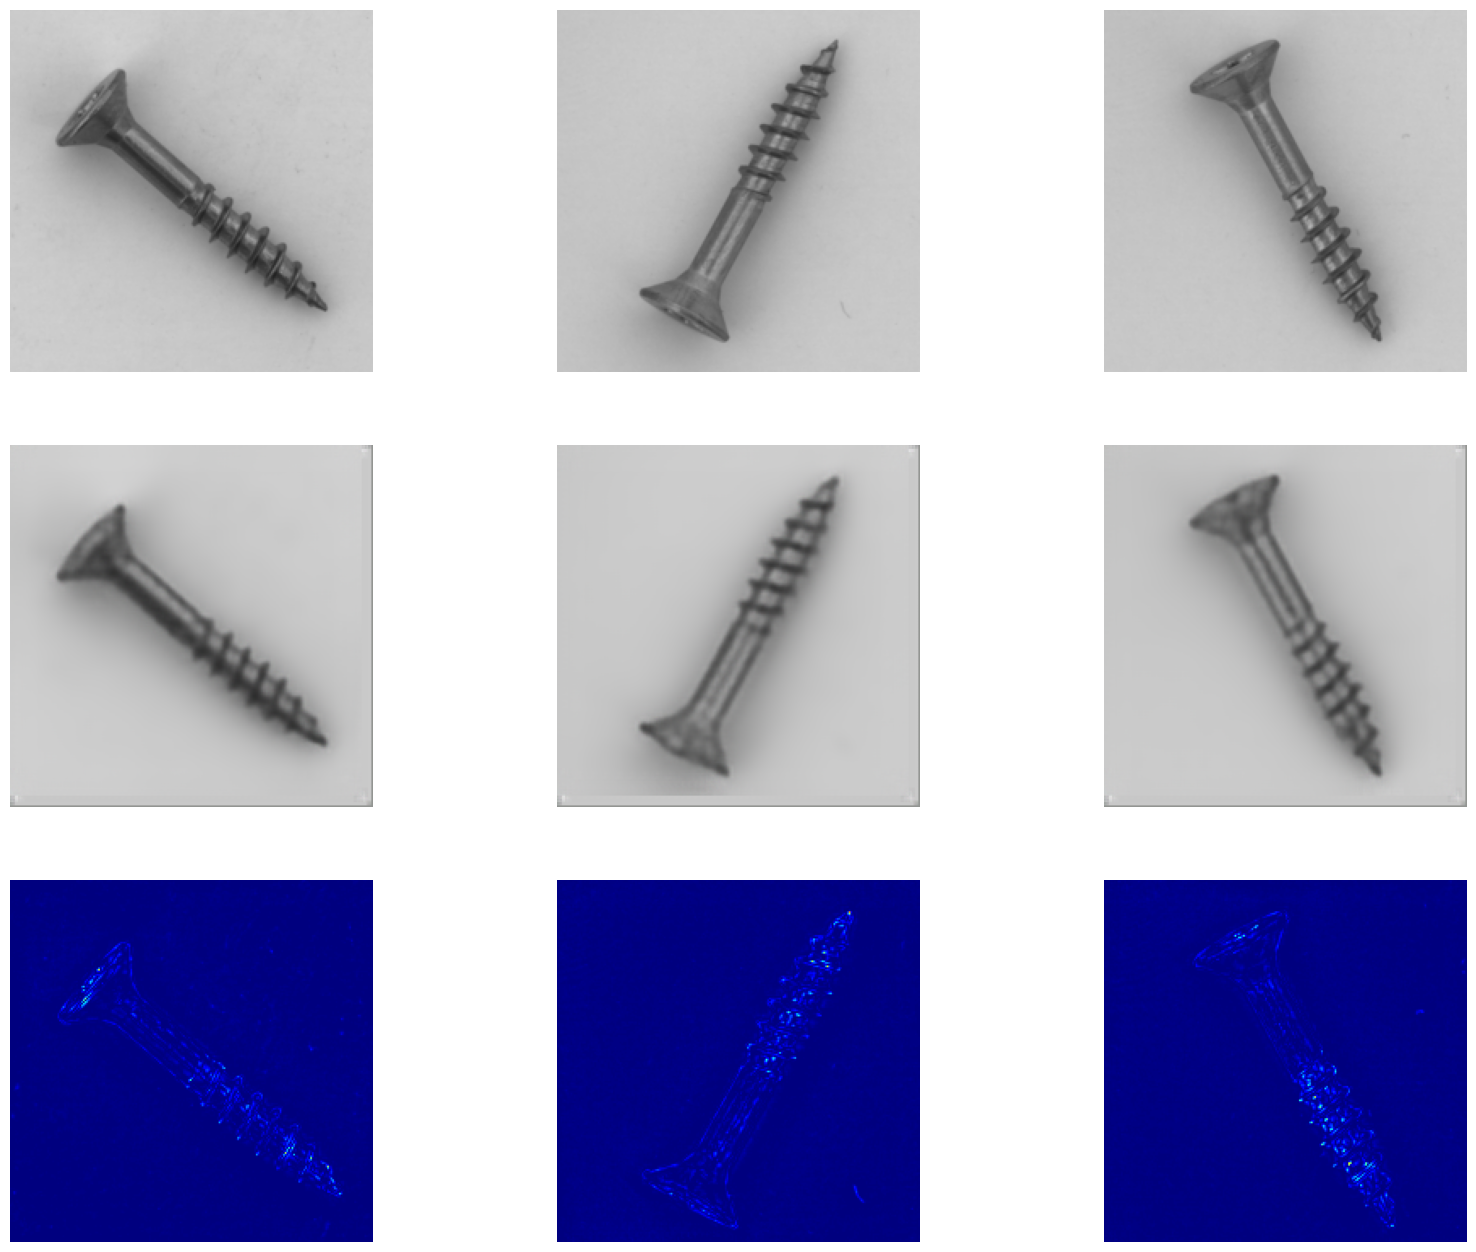

In [14]:
with torch.no_grad():
    for data, _ in train_loader:

        recon = model(data)
        break

recon_error = ((data - recon) ** 2).mean(axis = 1)
print(recon_error.shape)

plt.figure(dpi = 250)
fig, ax = plt.subplots(3, 3, figsize = (5 * 4, 4 * 4))
for i in range(3):
    ax[0, i].imshow(data[i].cpu().numpy().transpose((1, 2, 0)))
    ax[1, i].imshow(recon[i].cpu().numpy().transpose((1, 2, 0)))
    ax[2, i].imshow(recon_error[i][0:-10, 0:-10].cpu().numpy(), cmap = 'jet', vmax = torch.max(recon_error[i]))
    ax[0, i].axis('OFF')
    ax[1, i].axis('OFF')
    ax[2, i].axis('OFF')
plt.show()

reconstruction of bad images

<Figure size 1600x1200 with 0 Axes>

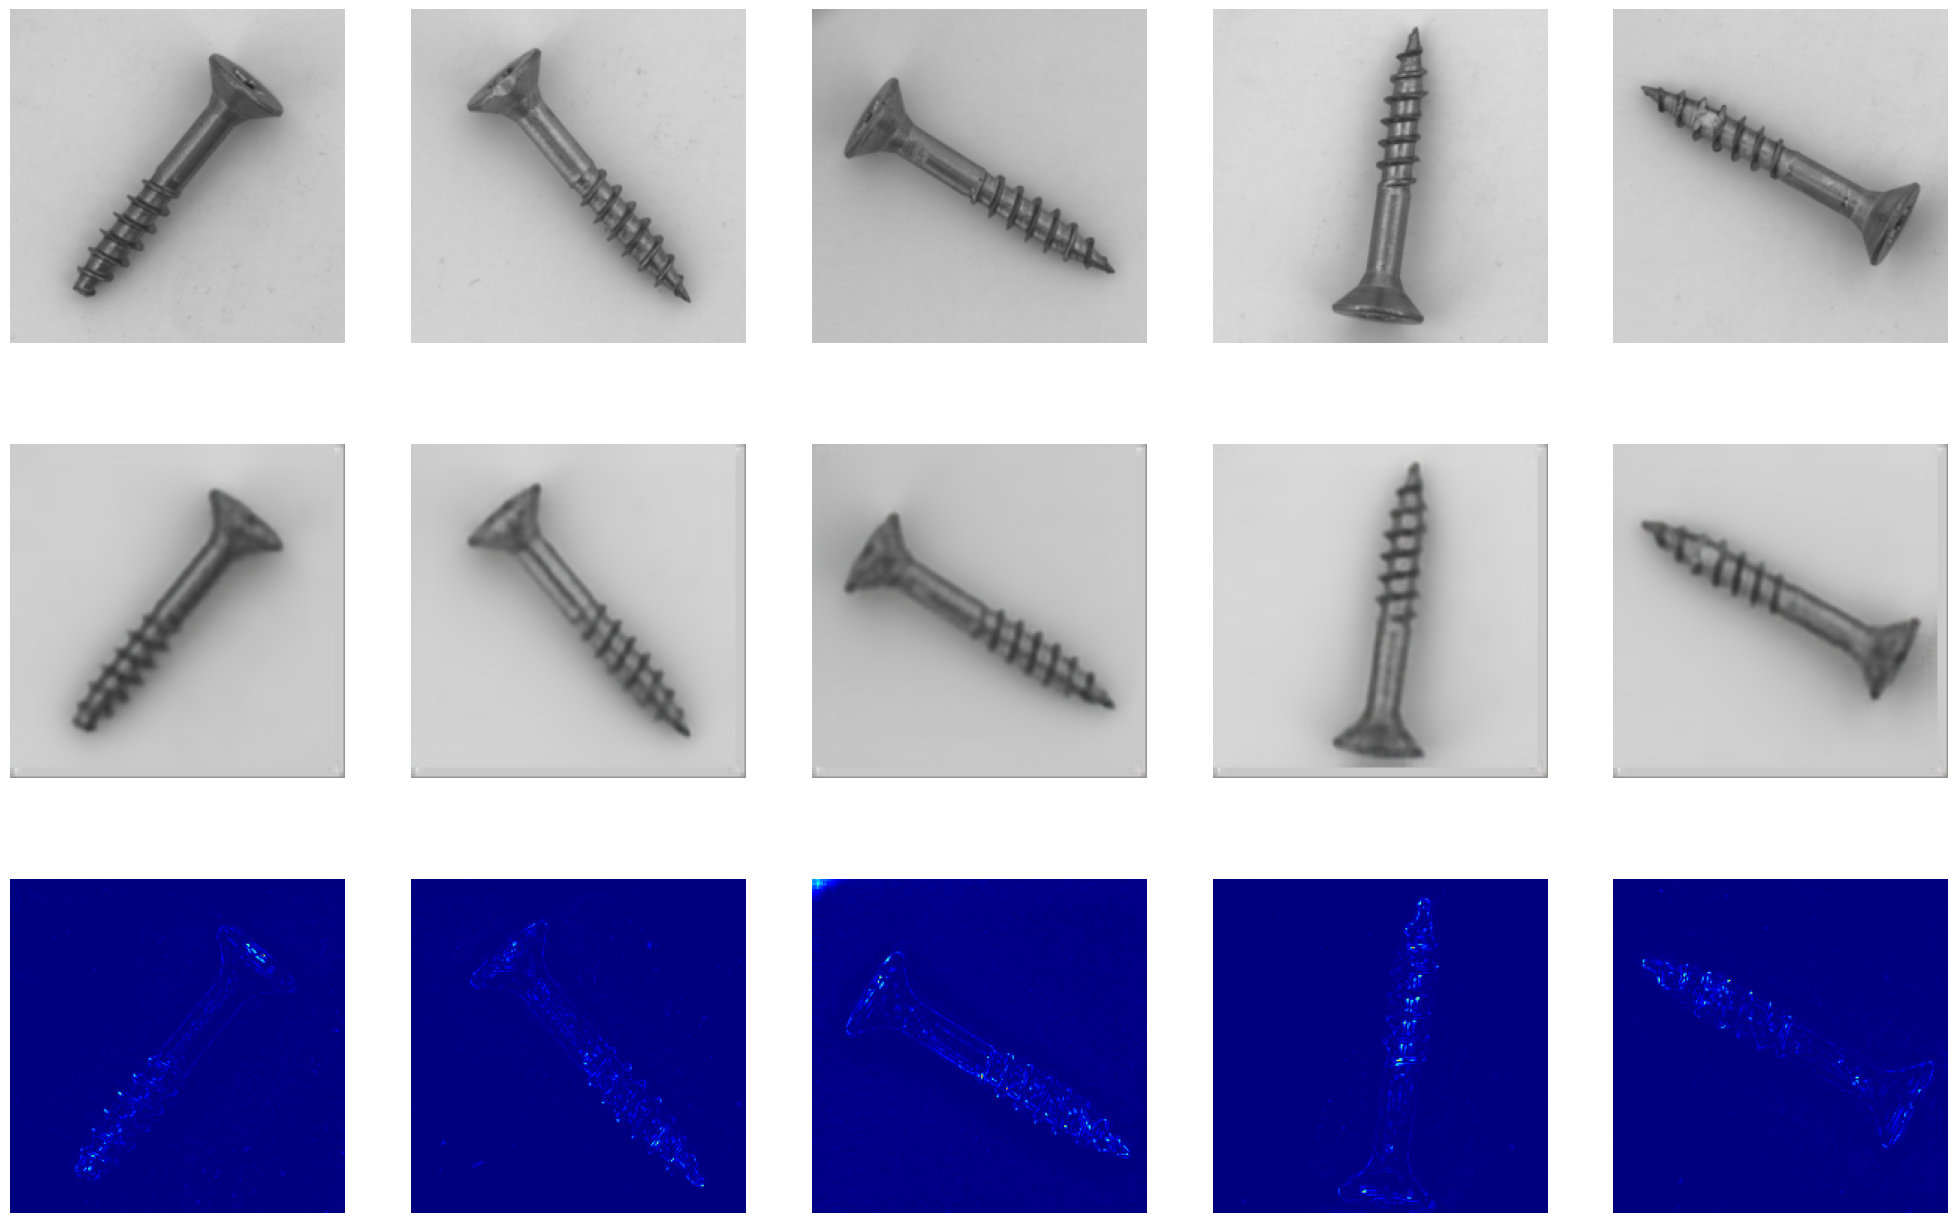

In [15]:
test_image_1 = transform(Image.open(r'D:\Users\A.M. Reza\VSCodeProjects\Python\compvis\capstone\screw\test\manipulated_front\000.png').convert('RGB'))
test_image_2 = transform(Image.open(r'D:\Users\A.M. Reza\VSCodeProjects\Python\compvis\capstone\screw\test\scratch_head\000.png').convert('RGB'))
test_image_3 = transform(Image.open(r'D:\Users\A.M. Reza\VSCodeProjects\Python\compvis\capstone\screw\test\scratch_neck\000.png').convert('RGB'))
test_image_4 = transform(Image.open(r'D:\Users\A.M. Reza\VSCodeProjects\Python\compvis\capstone\screw\test\thread_side\000.png').convert('RGB'))
test_image_5 = transform(Image.open(r'D:\Users\A.M. Reza\VSCodeProjects\Python\compvis\capstone\screw\test\thread_top\000.png').convert('RGB'))

data = torch.stack([test_image_1, test_image_2, test_image_3, test_image_4, test_image_5])

with torch.no_grad():
    recon = model(data)

recon_error = ((data - recon) ** 2).mean(axis = 1)

plt.figure(dpi = 250)
fig, ax = plt.subplots(3, 5, figsize = (5 * 5, 4 * 4))
for i in range(5):
    ax[0, i].imshow(data[i].cpu().numpy().transpose((1, 2, 0)))
    ax[1, i].imshow(recon[i].cpu().numpy().transpose((1, 2, 0)))
    ax[2, i].imshow(recon_error[i][0:-10, 0:-10].cpu().numpy(), cmap = 'jet', vmax = torch.max(recon_error[i]))
    ax[0, i].axis('OFF')
    ax[1, i].axis('OFF')
    ax[2, i].axis('OFF')

plt.show()

obtain the fault detection accuracy

In [16]:
RECON_ERROR  = [] 
with torch.no_grad():
    for data, _ in train_loader:
        recon = model(data)
        data_recon_squared_mean = ((data - recon) ** 2).mean(axis = (1))[:,0:-10, 0: -10].mean(axis = (1, 2))

        RECON_ERROR.append(data_recon_squared_mean)

RECON_ERROR = torch.cat(RECON_ERROR).cpu().numpy()



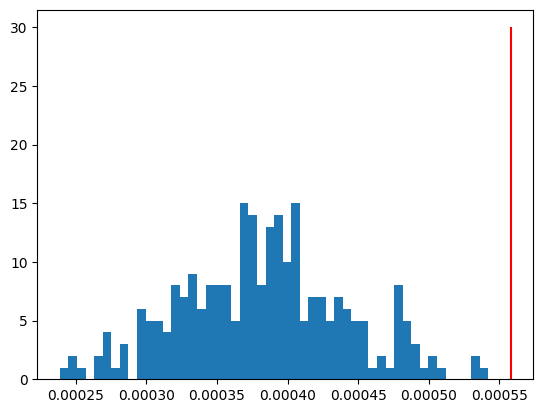

In [17]:
best_threshold = np.mean(RECON_ERROR) + 3 * np.std(RECON_ERROR)
 
plt.hist(RECON_ERROR, bins = 50)
plt.vlines(x = best_threshold, ymin = 0, ymax = 30, color = 'r')
plt.show()

In [23]:
y_true = []
y_pred = []
y_score = []

model.eval()

with torch.no_grad():

    test_path = Path('screw/test')

    for path in test_path.glob('*/*.png'):
        fault_type = path.parts[-2]
        
        test_image = transform(Image.open(path).convert('RGB')).unsqueeze(0)
        recon_image = model(test_image)

        y_score_image = ((test_image - recon_image) ** 2).mean(axis = (1))[:,0:-10, 0: -10].mean()
        y_pred_image = 1 * (y_score_image >= best_threshold)
        y_true_image = 0 if fault_type == 'good' else 1

        y_true.append(y_true_image)
        y_pred.append(y_pred_image.cpu())
        y_score.append(y_score_image.cpu())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_score = np.array(y_score)
    

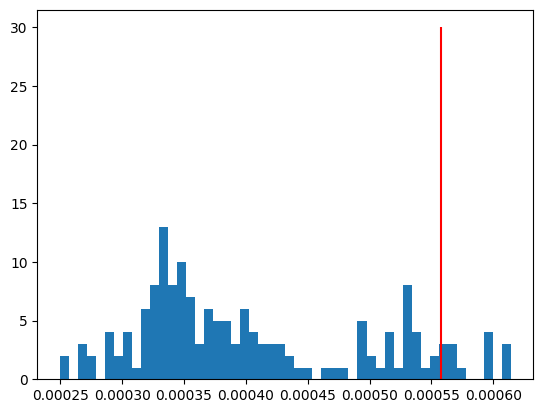

In [29]:
plt.hist(y_score, bins = 50)
plt.vlines(x = best_threshold, ymin = 0, ymax = 30, color = 'r')
plt.show()

AUC-ROC Score:  0.002254560360729658


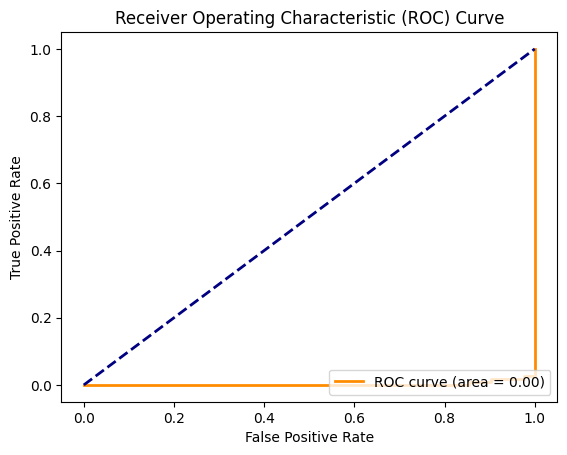

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, f1_score
import seaborn as sns

auc_roc_score = roc_auc_score(y_true, y_score)
print("AUC-ROC Score: ", auc_roc_score)

fpr, tpr, thresholds = roc_curve(y_true, y_score)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_roc_score)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()